# Dataset Movie Rating (Regresi)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Data Loading

movie_df = pd.read_csv('https://raw.githubusercontent.com/FTDS-learning-materials/phase-1/master/w1/P1W1D4AM%20-%20Linear%20Regression%20-%20Movie%20Ratings.csv')
movie_df

,Avg_age_actors,Marketing_expense,Wardrobe_expense,Budget,Lead_actor_rating,Lead_actrees_rating,Director_rating,Producer_rating,Movie_length,Trailer_views,Twitter_hastags,Total_cinemas,Movie_rating
0,23,20126,59620,36524125,7.825,8.095,7.910,7.995,138.7,527367,22384,49400,7.94
1,42,20546,69140,35668655,7.505,7.650,7.440,7.470,152.4,494055,24346,46200,7.44
2,38,20546,69140,39912675,7.485,7.570,7.495,7.515,134.6,547051,202240,45800,7.44
3,45,20647,59360,38873890,6.895,7.035,6.920,7.020,119.3,516279,22534,47200,8.26
4,55,21381,59360,39701585,6.920,7.070,6.815,7.070,127.7,531448,22579,39500,8.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,27,21253,78860,36624115,8.680,8.775,8.620,8.970,142.6,492480,24358,56100,6.80
502,20,20905,78860,33996600,8.780,8.945,8.770,8.930,150.2,482875,26330,60000,7.80
503,31,21215,78860,38751680,8.830,8.970,8.855,9.010,164.5,532239,24382,57600,7.80
504,47,22192,78860,37740670,8.730,8.845,8.800,8.845,162.8,496077,30352,60700,6.80


In [ ]:
# Splitting between `X` and `y`

X = movie_df.drop(['Movie_rating'], axis=1) #fitur
y = movie_df['Movie_rating'] #target
X.head()

,Avg_age_actors,Marketing_expense,Wardrobe_expense,Budget,Lead_actor_rating,Lead_actrees_rating,Director_rating,Producer_rating,Movie_length,Trailer_views,Twitter_hastags,Total_cinemas
0,23,20126,59620,36524125,7.825,8.095,7.910,7.995,138.7,527367,22384,49400
1,42,20546,69140,35668655,7.505,7.650,7.440,7.470,152.4,494055,24346,46200
2,38,20546,69140,39912675,7.485,7.570,7.495,7.515,134.6,547051,202240,45800
3,45,20647,59360,38873890,6.895,7.035,6.920,7.020,119.3,516279,22534,47200
4,55,21381,59360,39701585,6.920,7.070,6.815,7.070,127.7,531448,22579,39500


Untuk menghemat waktu kita akan drop beberapa kolom yang tidak kita gunakan sebagai fitur.

In [ ]:
# Drop column `Total_cinemas`, `Trailer_views`, and `Movie_length`

X = X.drop(['Total_cinemas', 'Trailer_views', 'Movie_length'], axis=1)
X.head()

,Avg_age_actors,Marketing_expense,Wardrobe_expense,Budget,Lead_actor_rating,Lead_actrees_rating,Director_rating,Producer_rating,Twitter_hastags
0,23,20126,59620,36524125,7.825,8.095,7.910,7.995,22384
1,42,20546,69140,35668655,7.505,7.650,7.440,7.470,24346
2,38,20546,69140,39912675,7.485,7.570,7.495,7.515,202240
3,45,20647,59360,38873890,6.895,7.035,6.920,7.020,22534
4,55,21381,59360,39701585,6.920,7.070,6.815,7.070,22579


In [ ]:
# Splitting Dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print('Train size : ', X_train.shape)
print('Test size  : ', X_test.shape)

Train size :  (354, 9)
Test size  :  (152, 9)


In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Regularization

In [ ]:
# Create a function to calculate the evaluation results
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

eval_results = {
    'name': [],
    'MAE - Train': [],
    'MAE - Test': [],
    'MSE - Train': [],
    'MSE - Test': [],
    'RMSE - Train': [],
    'RMSE - Test': [],
    'R2 Score - Train': [],
    'R2 Score - Test': []
}

def model_evaluation(name, model, X_train, X_test, y_train, y_test):
  # Predict Train-Set and Test-Set
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)

  # Model evaluation using different metrics
  mae_train = mean_absolute_error(y_train, y_pred_train)
  mae_test = mean_absolute_error(y_test, y_pred_test)

  mse_train = mean_squared_error(y_train, y_pred_train)
  mse_test = mean_squared_error(y_test, y_pred_test)

  rmse_train = mean_squared_error(y_train, y_pred_train, squared=False)
  rmse_test = mean_squared_error(y_test, y_pred_test, squared=False)

  r2score_train = r2_score(y_train, y_pred_train)
  r2score_test = r2_score(y_test, y_pred_test)

  # Save into dictionary
  eval_results['name'].append(name)
  eval_results['MAE - Train'].append(round(mae_train, 5))
  eval_results['MAE - Test'].append(round(mae_test, 5))
  eval_results['MSE - Train'].append(round(mse_train, 5))
  eval_results['MSE - Test'].append(round(mse_test, 5))
  eval_results['RMSE - Train'].append(round(rmse_train, 5))
  eval_results['RMSE - Test'].append(round(rmse_test, 5))
  eval_results['R2 Score - Train'].append(round(r2score_train, 5))
  eval_results['R2 Score - Test'].append(round(r2score_test, 5))

### Lasso Regression (L1)

In [ ]:
# Training using Lasso Regression - with alpha=0.01
from sklearn.linear_model import Lasso

model_lasso_alpha_01 = Lasso(alpha=0.01)
model_lasso_alpha_01.fit(X_train_scaled, y_train)

# Evaluate the model
model_evaluation('Lasso with alpha=0.01', model_lasso_alpha_01, X_train_scaled, X_test_scaled, y_train, y_test)
eval_results_df = pd.DataFrame(eval_results)
eval_results_df.set_index('name').T

name,Lasso with alpha=0.01
MAE - Train,0.53979
MAE - Test,0.55930
MSE - Train,0.38842
MSE - Test,0.41057
RMSE - Train,0.62323
RMSE - Test,0.64076
R2 Score - Train,0.10576
R2 Score - Test,0.05256


In [ ]:
# Training using Lasso Regression - with alpha=10
from sklearn.linear_model import Lasso

model_lasso_alpha_10 = Lasso(alpha=10)
model_lasso_alpha_10.fit(X_train_scaled, y_train)

# Evaluate the model
model_evaluation('Lasso with alpha=10', model_lasso_alpha_10, X_train_scaled, X_test_scaled, y_train, y_test)
eval_results_df = pd.DataFrame(eval_results)
eval_results_df.set_index('name').T

name,Lasso with alpha=0.01,Lasso with alpha=10
MAE - Train,0.53979,0.54581
MAE - Test,0.55930,0.55440
MSE - Train,0.38842,0.43435
MSE - Test,0.41057,0.43474
RMSE - Train,0.62323,0.65905
RMSE - Test,0.64076,0.65935
R2 Score - Train,0.10576,0.00000
R2 Score - Test,0.05256,-0.00321


In [ ]:
# Compare the coefficients

print('Lasso Regression - alpha=0.01')
print('Coefficients : ', model_lasso_alpha_01.coef_)
print('Intercept    : ', model_lasso_alpha_01.intercept_)
print('')

print('Lasso Regression - alpha=10.0')
print('Coefficients : ', model_lasso_alpha_10.coef_)
print('Intercept    : ', model_lasso_alpha_10.intercept_)
print('')

Lasso Regression - alpha=0.01
Coefficients :  [-0.01014155 -0.0400657  -0.1057816   0.11385585  0.          0.
  0.          0.         -0.00841796]
Intercept    :  7.799661016949151

Lasso Regression - alpha=10.0
Coefficients :  [-0. -0. -0.  0. -0. -0. -0. -0. -0.]
Intercept    :  7.799661016949151



Dapat dilihat bahwa **Lasso Regression** akan membuat beberapa koefisien menjadi **0**. Semakin besar nilai **alpha** , semakin besar penalti yang diberikan, yang dapat mengakibatkan lebih banyak koefisien memiliki nilai **0**.

### Ridge Regression (L2)

In [ ]:
# Training using Ridge Regression - with alpha=1.0
from sklearn.linear_model import Ridge

model_ridge_alpha_1 = Ridge(alpha=1.0)
model_ridge_alpha_1.fit(X_train_scaled, y_train)

# Evaluate the model
model_evaluation('Ridge with alpha=1', model_ridge_alpha_1, X_train_scaled, X_test_scaled, y_train, y_test)
eval_results_df = pd.DataFrame(eval_results)
eval_results_df.set_index('name').T

name,Lasso with alpha=0.01,Lasso with alpha=10,Ridge with alpha=1
MAE - Train,0.53979,0.54581,0.53896
MAE - Test,0.55930,0.55440,0.56205
MSE - Train,0.38842,0.43435,0.38691
MSE - Test,0.41057,0.43474,0.41310
RMSE - Train,0.62323,0.65905,0.62202
RMSE - Test,0.64076,0.65935,0.64273
R2 Score - Train,0.10576,0.00000,0.10923
R2 Score - Test,0.05256,-0.00321,0.04673


In [ ]:
# Training using Ridge Regression - with alpha=100.0
from sklearn.linear_model import Ridge

model_ridge_alpha_100 = Ridge(alpha=100.0)
model_ridge_alpha_100.fit(X_train_scaled, y_train)

# Evaluate the model
model_evaluation('Ridge with alpha=100', model_ridge_alpha_100, X_train_scaled, X_test_scaled, y_train, y_test)
eval_results_df = pd.DataFrame(eval_results)
eval_results_df.set_index('name').T

name,Lasso with alpha=0.01,Lasso with alpha=10,Ridge with alpha=1,Ridge with alpha=100
MAE - Train,0.53979,0.54581,0.53896,0.53915
MAE - Test,0.55930,0.55440,0.56205,0.55768
MSE - Train,0.38842,0.43435,0.38691,0.38916
MSE - Test,0.41057,0.43474,0.41310,0.40830
RMSE - Train,0.62323,0.65905,0.62202,0.62382
RMSE - Test,0.64076,0.65935,0.64273,0.63898
R2 Score - Train,0.10576,0.00000,0.10923,0.10405
R2 Score - Test,0.05256,-0.00321,0.04673,0.05780


In [ ]:
print('Ridge Regression - alpha=1.0')
print('Coefficients : ', model_ridge_alpha_1.coef_)
print('Intercept    : ', model_ridge_alpha_1.intercept_)
print('')

print('Ridge Regression - alpha=100.0')
print('Coefficients : ', model_ridge_alpha_100.coef_)
print('Intercept    : ', model_ridge_alpha_100.intercept_)
print('')

Ridge Regression - alpha=1.0
Coefficients :  [-0.02021597 -0.05116174 -0.13412165  0.11526778 -0.12603359  0.15780745
  0.11503499 -0.11470918 -0.01866126]
Intercept    :  7.799661016949151

Ridge Regression - alpha=100.0
Coefficients :  [-0.01623581 -0.04458301 -0.09253584  0.09980576 -0.00200833  0.00290181
  0.00211262 -0.00432743 -0.01377582]
Intercept    :  7.799661016949151



Anda dapat melihat bahwa koefisiennya menjadi lebih kecil seiring meningkatnya nilai **alpha**, namun tidak ada nilai koefisien yang **0**. Ini berbeda dengan lasso yang bisa mengakibatkan koefisien menjadi **0**.

# Dataset Prediksi Diabetes (Klasifikasi)

## A. Import Library

In [ ]:
# Import Library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

## B. Data Loading & Preprocessing

Untuk tugas ini, kita menggunakan dataset yang menunjukkan apakah seseorang menderita diabetes atau tidak.

Sumber dataset: [tautan](https://raw.githubusercontent.com/FTDS-learning-materials/phase-1/master/w1/P1W1D5AM%20-%20Diabetes.csv)

In [ ]:
# Data Loading

df = pd.read_csv('https://raw.githubusercontent.com/FTDS-learning-materials/phase-1/master/w2/P1W2D1AM%20-%20Classification%20Model%20Evaluation%20-%20Diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Check Columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# Check Distribution of Target Class

df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


Data yang kita miliki tidak seimbang.

In [ ]:
# Split between Features and Target
X = df.drop("Outcome", axis=1)
y = df['Outcome']

# Split between Train-Set and Test-Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=46)

print('Train Size : ', y_train.shape)
print('Test Size  : ', y_test.shape)

Train Size :  (652,)
Test Size  :  (116,)


In [ ]:
# Check Class Distribution  Test-Set

np.array(np.unique(y_test, return_counts=True)).T

array([[ 0, 79],
       [ 1, 37]])

In [ ]:
# Feature Scaling dengan StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## C. Model Definition & Model Training

Pada bagian ini kita akan bereksperimen dengan menggunakan Logistic Regression dan Logistic Regression with Balancing.

### Logistic Regression

Dari dokumentasi **Logistic Regression** di Scikit-Learn ([sumber](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)), ada beberapa **hyperparameter** yang bisa kita atur sebelum melatih model, seperti:
- **penalty**
- **C**
- **class_weight**


Kita akan menggunakan **Logistic Regression** dengan **C=1.2**. `Penalty` dengan nilai default yaitu `l2`, `class_weight` dengan nilai default yaitu `None`.


In [ ]:
# Model Training using Logistic Regression

logreg_1 = LogisticRegression(penalty='l2', C=1.2, class_weight=None, random_state=10)
logreg_1.fit(X_train_scaled, y_train)

LogisticRegression(C=1.2, random_state=10)


Keterangan:
- C adalah parameter yang mengontrol regulasi dalam model Logistic Regression.
- C mengatur seberapa keras model harus berusaha untuk menghindari kesalahan dalam prediksi, dengan cara meminimalkan `loss function`.
- Jika nilai C terlalu besar dapat menyebabkan **overfitting**, karena model akan terlalu menyesuaikan diri dengan data pelatihan dan gagal menggeneralisasi dengan baik ke data baru.
- Jika C terlalu kecil dapat menyebabkan **underfitting**, karena model tidak cukup kompleks untuk menangkap pola dari data pelatihan.
- **penalty** adalah parameter regularisasi yang bisa digunakan untuk meningkatkan performa model dan mencegah overfitting.
- **class_weight** adalah parameter yang bisa digunakan untuk menangani imbalance data.


In [ ]:
# Set parameters for Logistic Regression with class_weight='balanced'
logreg_2 = LogisticRegression(penalty='l2', C=1.2, class_weight='balanced', random_state=10)
logreg_2.fit(X_train_scaled, y_train)

LogisticRegression(C=1.2, class_weight='balanced', random_state=10)

## D. Model Evaluation

In [ ]:
# Model Prediction

y_pred_train_logreg_1 = logreg_1.predict(X_train_scaled)
y_pred_test_logreg_1 = logreg_1.predict(X_test_scaled)

y_pred_train_logreg_2 = logreg_2.predict(X_train_scaled)
y_pred_test_logreg_2 = logreg_2.predict(X_test_scaled)

### D.1 - Confusion Matrix & Classification Report (with default threshold=0.5)

Default threshold yang digunkan keitka kita melakukan prediksi adalah `0.5`.

In [ ]:
# Confusion Matrix - Train Set

from sklearn.metrics import confusion_matrix

cm_train_logreg_1 = confusion_matrix(y_train, y_pred_train_logreg_1)

print('Confusion Matrix - Logistic Regression without Balancing: \n', cm_train_logreg_1)

cm_train_logreg_2 = confusion_matrix(y_train, y_pred_train_logreg_2)

print('Confusion MatBalancedistic Regression with Balancing : \n', cm_train_logreg_2)

Confusion Matrix - Logistic Regression without Balancing: 
 [[374  47]
 [ 93 138]]
Confusion MatBalancedistic Regression with Balancing : 
 [[325  96]
 [ 63 168]]


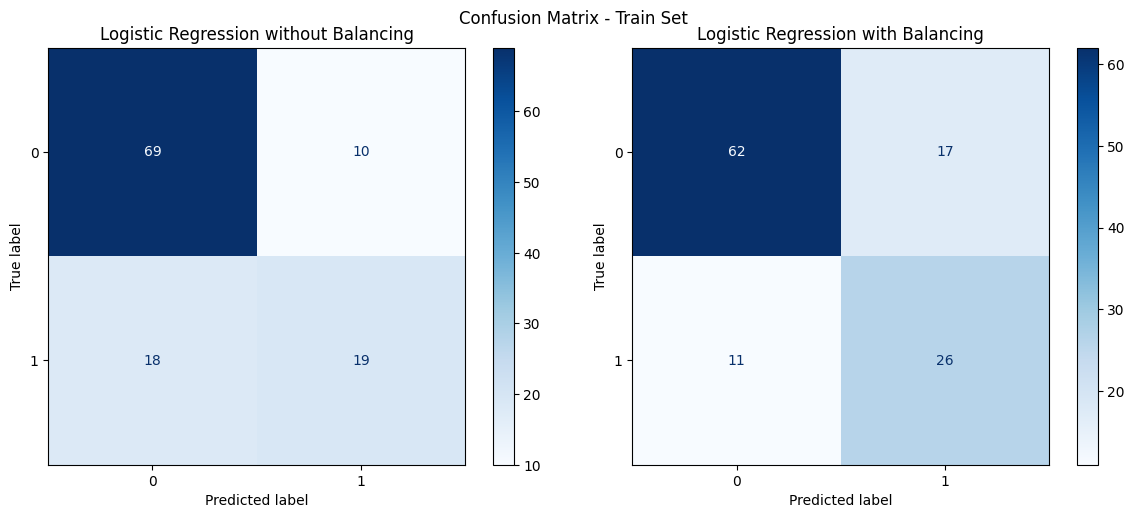

In [ ]:
# Confusion Matrix Display - Train Set

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(logreg_1, X_test_scaled, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression without Balancing')

ConfusionMatrixDisplay.from_estimator(logreg_2, X_test_scaled, y_test, ax=axes[1], cmap='Blues')
axes[1].set_title('Logistic Regression with Balancing')
plt.suptitle('Confusion Matrix - Train Set')
plt.tight_layout()
plt.show()


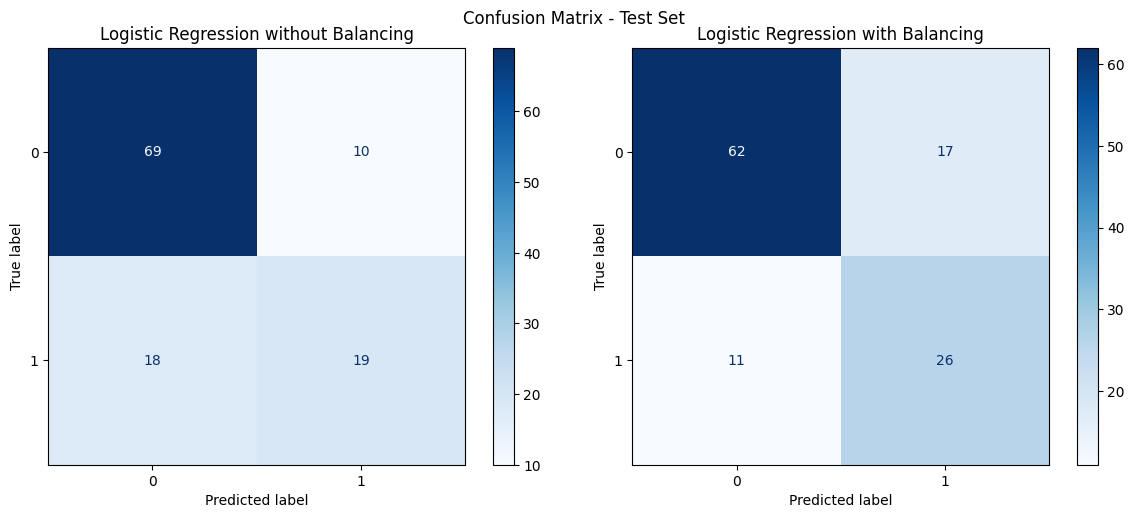

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(logreg_1, X_test_scaled, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression without Balancing')

ConfusionMatrixDisplay.from_estimator(logreg_2, X_test_scaled, y_test, ax=axes[1], cmap='Blues')
axes[1].set_title('Logistic Regression with Balancing')
plt.suptitle('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

In [ ]:
# Model Evaluation - Train Set
print('classification report Train Set - Logistic Regession without Balancing')
print(classification_report(y_train, y_pred_train_logreg_1))

# Model Evaluation - Test Set
print('classification report Test Set - Logistic Regession without Balancing')
print(classification_report(y_test, y_pred_test_logreg_1))

classification report Train Set - Logistic Regession without Balancing
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       421
           1       0.75      0.60      0.66       231

    accuracy                           0.79       652
   macro avg       0.77      0.74      0.75       652
weighted avg       0.78      0.79      0.78       652

classification report Test Set - Logistic Regession without Balancing
              precision    recall  f1-score   support

           0       0.79      0.87      0.83        79
           1       0.66      0.51      0.58        37

    accuracy                           0.76       116
   macro avg       0.72      0.69      0.70       116
weighted avg       0.75      0.76      0.75       116



In [ ]:
# Model Evaluation - Train Set
print('classification report Train Set - Logistic Regression with Balancing')
print(classification_report(y_train, y_pred_train_logreg_2))

print('classification report Test Set - Logistic Regression with Balancing')
print(classification_report(y_test, y_pred_test_logreg_2))

classification report Train Set - Logistic Regression with Balancing
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       421
           1       0.64      0.73      0.68       231

    accuracy                           0.76       652
   macro avg       0.74      0.75      0.74       652
weighted avg       0.77      0.76      0.76       652

classification report Test Set - Logistic Regression with Balancing
              precision    recall  f1-score   support

           0       0.85      0.78      0.82        79
           1       0.60      0.70      0.65        37

    accuracy                           0.76       116
   macro avg       0.73      0.74      0.73       116
weighted avg       0.77      0.76      0.76       116



In [ ]:
# Get Precision Score and Recall Score

from sklearn.metrics import precision_score, recall_score

print('Precision - Logistic Regression without Balancing : ', precision_score(y_test, y_pred_test_logreg_1))
print('Recall  - Logistic Regression without Balancing : ', recall_score(y_test, y_pred_test_logreg_1))
print('Precision - Logistic Regression with Balancing : ', precision_score(y_test, y_pred_test_logreg_2))
print('Recall  - Logistic Regression with Balancing : ', recall_score(y_test, y_pred_test_logreg_2))

Precision - Logistic Regression without Balancing :  0.6551724137931034
Recall  - Logistic Regression without Balancing :  0.5135135135135135
Precision - Logistic Regression with Balancing :  0.6046511627906976
Recall  - Logistic Regression with Balancing :  0.7027027027027027


### D.2 - Classification Report (with threshold=0.35)

Sekarang kita akan coba atur threshold untuk model logistic regression tanpa balancing dari yang defaultnya adalah `0.5` menjadi `0.35`

In [ ]:
# Change Threshold

y_pred_new_proba = logreg_1.predict_proba(X_test_scaled)
y_pred_new_test = np.where(y_pred_new_proba[:,1] >= 0.35, 1, 0)

print(classification_report(y_test, y_pred_new_test))
print('Precision - Logistic Regression : ', precision_score(y_test, y_pred_new_test))
print('Recall - Logistic Regression : ', recall_score(y_test, y_pred_new_test))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        79
           1       0.63      0.73      0.68        37

    accuracy                           0.78       116
   macro avg       0.75      0.76      0.75       116
weighted avg       0.79      0.78      0.78       116

Precision - Logistic Regression :  0.627906976744186
Recall - Logistic Regression :  0.7297297297297297


**Latihan**:

- Coba ubahlah nilai thresholdnya menjadi 0.7, apa yang terjadi pada precision dan recall-nya?
- Cek juga skor precision dan recall jika menggunakan `Logistic Regression dengan Balancing` dan threshold 0.7

### D.3 - ROC-AUC

In [ ]:
# Get FPR, TPR, and AUC Score from Logistic Regression with C=1.2

from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba_logreg_1 = logreg_1.predict_proba(X_test_scaled)[:, 1]
fpr_logreg_1, tpr_logreg_1, _ = roc_curve(y_test, y_pred_proba_logreg_1)
auc_logreg_1 = roc_auc_score(y_test, y_pred_proba_logreg_1)

print('AUC Score : ', auc_logreg_1)

AUC Score :  0.8279165241190558


In [ ]:
# Check FPR and TPR of Logistic Regression with C=1

pd.DataFrame({'FPR': fpr_logreg_1, 'TPR': tpr_logreg_1})

,FPR,TPR
0,0.000000,0.000000
1,0.000000,0.027027
2,0.000000,0.297297
3,0.025316,0.297297
4,0.025316,0.351351
5,0.075949,0.351351
6,0.075949,0.459459
7,0.113924,0.459459
8,0.113924,0.486486
9,0.126582,0.486486


Selanjutnya kita akan coba membuat model logistic regression dengan nilai C=0.005 yang nantinya akan kita bandingkan dnegan C=1.2

In [ ]:
# Model Training using Logistic Regression with C=0.005
logreg_5 = LogisticRegression(C=0.005, random_state=10)
logreg_5.fit(X_train_scaled, y_train)

# Model Prediction
y_pred_train_logreg_5 = logreg_5.predict(X_train_scaled)
y_pred_test_logreg_5 = logreg_5.predict(X_test_scaled)

# Model Evaluation - Test Set
print(classification_report(y_test, y_pred_test_logreg_5))

              precision    recall  f1-score   support

           0       0.77      0.94      0.85        79
           1       0.75      0.41      0.53        37

    accuracy                           0.77       116
   macro avg       0.76      0.67      0.69       116
weighted avg       0.76      0.77      0.74       116



In [ ]:
# Get FPR, TPR, and AUC Score from Logistic Regression with C=0.005

from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba_logreg_5 = logreg_5.predict_proba(X_test_scaled)[:, 1]
fpr_logreg_5, tpr_logreg_5, _ = roc_curve(y_test, y_pred_proba_logreg_5)
auc_logreg_5 = roc_auc_score(y_test, y_pred_proba_logreg_5)

print('AUC Score : ', auc_logreg_5)

AUC Score :  0.8357851522408485


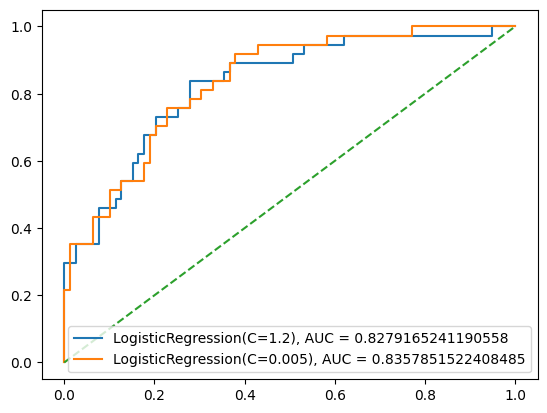

In [ ]:
# Plot ROC-AUC Curve

plt.figure(0).clf()
plt.plot(fpr_logreg_1, tpr_logreg_1, label='LogisticRegression(C=1.2), AUC = ' + str(auc_logreg_1))
plt.plot(fpr_logreg_5, tpr_logreg_5, label='LogisticRegression(C=0.005), AUC = ' + str(auc_logreg_5))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend(loc=0);

**Latihan:**

- Lakukannya uji coba Logisitic Regression dengan nilai parameter yang berbeda-beda agar anda dapat memahami efek dari perubahan pada parameter tersebut.
